In [21]:
import os
import gc
import ot
import pickle
import anndata
import scanpy as sc
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import sparse
from scipy.stats import spearmanr, pearsonr
from scipy.spatial import distance_matrix
import matplotlib.pyplot as plt

import commot as ct

In [46]:
adata = sc.read_visium(path="./E-MTAB-14121/V19S23-092-C1/")
adata.var_names_make_unique()
adata.obs['sample_id'] = "V19S23-092-C1"

In [47]:
sc.pp.normalize_total(adata , inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=10)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.4)

In [48]:
annotations = pd.read_csv("./E-MTAB-14121/hs_visium_merged_histo_annotations.csv" , index_col=0)
annotations = annotations[annotations['sample_slide_id'] == "V19S23-092-C1"]
sample_to_annotation = dict(zip(
    annotations.index, 
    annotations['annotation']
))
adata.obs['histology_annotation'] = adata.obs_names.map(sample_to_annotation)

In [49]:
niche = pd.read_csv("./niche.txt" , sep="\t")
niche = niche[niche['sample'] == "V19S23-092-C1"]
sample_to_niche = dict(zip(
    niche['barcode'], 
    niche['niche']
))
adata.obs['niche'] = adata.obs_names.map(sample_to_niche)

In [41]:
# LR=np.array([['FN1', 'ITGAV_ITGB1', 'FN1'],['FN1', 'ITGA5_ITGB1', 'FN1'],['FN1', 'CD44', 'FN1'],['FN1', 'ITGA8_ITGB1', 'FN1']],dtype=str)
# df_ligrec = pd.DataFrame(data=LR)
df_ligrec=ct.pp.ligand_receptor_database(database='CellChat', species='human')
df_ligrec

,0,1,2,3
0,TGFB1,TGFBR1_TGFBR2,TGFb,Secreted Signaling
1,TGFB2,TGFBR1_TGFBR2,TGFb,Secreted Signaling
2,TGFB3,TGFBR1_TGFBR2,TGFb,Secreted Signaling
3,TGFB1,ACVR1B_TGFBR2,TGFb,Secreted Signaling
4,TGFB1,ACVR1C_TGFBR2,TGFb,Secreted Signaling
...,...,...,...,...
1194,UTS2B,UTS2R,UROTENSIN,Secreted Signaling
1195,UTS2B,SSTR5,UROTENSIN,Secreted Signaling
1196,BAG6,NCR3,BAG,Secreted Signaling
1197,LGALS9,HAVCR2,GALECTIN,Secreted Signaling


In [42]:
# df_ligrec_filtered = ct.pp.filter_lr_database(df_ligrec, adata, min_cell_pct=0.05)
# df_ligrec_filtered.shape

In [43]:
ct.tl.spatial_communication(adata,
    database_name='user_database', df_ligrec=df_ligrec, dis_thr=500, heteromeric=True)

Text(0.5, 1.0, 'Receiver')

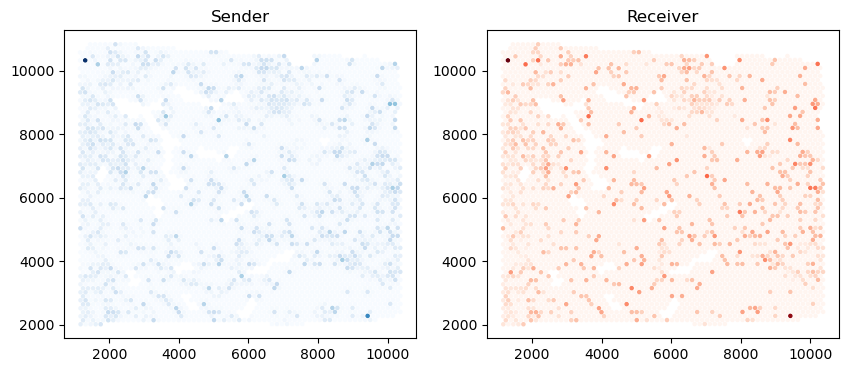

In [34]:
pts = adata.obsm['spatial']
s = adata.obsm['commot-user_database-sum-sender']['s-CCL18-ACKR1']
r = adata.obsm['commot-user_database-sum-receiver']['r-CCL18-ACKR1']
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].scatter(pts[:,0], pts[:,1], c=s, s=5, cmap='Blues')
ax[0].set_title('Sender')
ax[1].scatter(pts[:,0], pts[:,1], c=r, s=5, cmap='Reds')
ax[1].set_title('Receiver')

<Axes: >

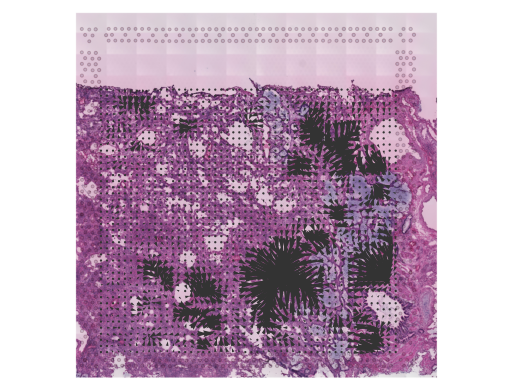

In [365]:
ct.tl.communication_direction(adata, database_name='user_database', lr_pair=('CCL18','ACKR1'), k=5)
ct.pl.plot_cell_communication(adata, database_name='user_database', lr_pair=('CCL18','ACKR1'), plot_method='grid', background_legend=True,
    scale=0.000015, ndsize=8, grid_density=1, summary='sender', background='image', clustering='leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995, 
    filename = "./V19S23-092-D1.pdf")

In [50]:
color_dict = {
    "Large Airway" : "#968ac1" , 
    "Blood Vessel" : "#c19b7c" , 
    "Suspect Fibrosis" : "#86bcab" , 
    "Diseased" : "#dd6f6f" , 
    "Inflammation" : "#9F5042" , 
    "Normal Alveolar and Other" : "#6a94a8"
}

In [51]:
adata.obsm['spatial_mirrored'] = adata.obsm['spatial'].copy()
adata.obsm['spatial_mirrored'][:, 1] = -adata.obsm['spatial'][:, 1]

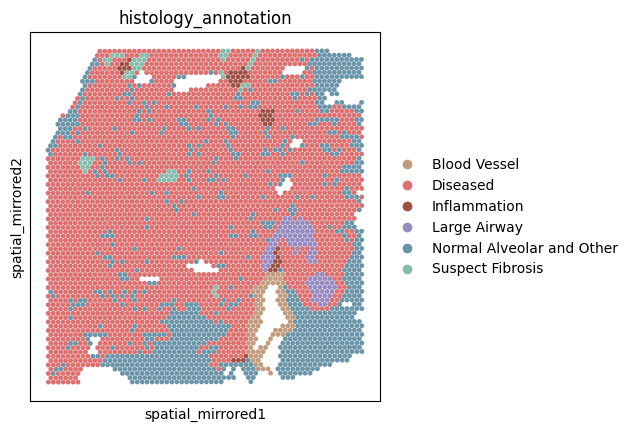

In [52]:
sc.pl.spatial(adata, color='histology_annotation', img_key='hires',
              basis="spatial_mirrored",  # Y坐标取负
              palette=color_dict, 
              show=True , 
              size = 1.5)

In [41]:
sc.pl.spatial(adata, color='histology_annotation', img_key='hires',
              basis="spatial_mirrored",  # Y坐标取负
              palette=color_dict, 
              show=False , 
              size = 1.5)
plt.savefig('./V19S23-092-B1_histo.pdf', dpi=300, bbox_inches='tight')
plt.close() 

In [42]:
color_niche = {
    "niche_0" : "#ab6881" , 
    "non-niche_0" : "#d3d3d4"
}

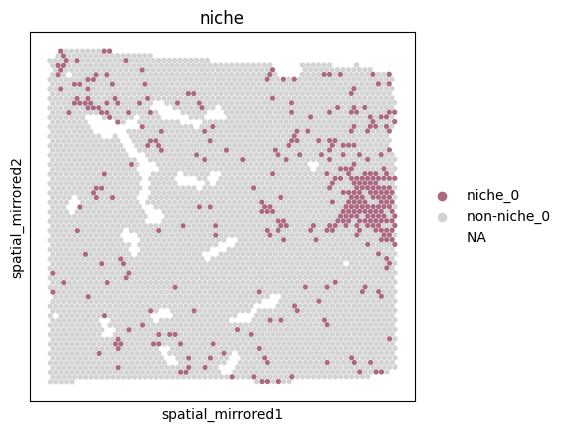

In [43]:
sc.pl.spatial(adata, color='niche', img_key='hires',
              basis="spatial_mirrored",  # Y坐标取负
              show=True , 
              palette=color_niche,
              size = 1.5)

In [44]:
sc.pl.spatial(adata, color='niche', img_key='hires',
              basis="spatial_mirrored",  # Y坐标取负
              show=False , 
              palette=color_niche,
              size = 1.5)
plt.savefig('./V19S23-092-B1_niche0.pdf', dpi=300, bbox_inches='tight')
plt.close() 

In [45]:
sc.pl.spatial(adata, color='niche', img_key='hires' ,
              show=False , 
              palette=color_niche,
              size = 1.5)
plt.savefig('./V19S23-092-B1_slice.pdf', dpi=300, bbox_inches='tight')
plt.close() 

In [ ]:
ct.tl.communication_direction(adata, database_name='user_database', lr_pair=('FN1','ITGA8_ITGB1'), k=5)
ct.pl.plot_cell_communication(adata, database_name='user_database', lr_pair=('FN1','ITGA8_ITGB1'), plot_method='grid', background_legend=True,
    scale=0.000015, ndsize=8, grid_density=1, summary='sender', background='image', clustering='leiden', cmap='Alphabet',
    normalize_v = True, normalize_v_quantile=0.995)

In [35]:
pd.DataFrame(
    adata.obsm['commot-user_database-sum-receiver'],
    index=adata.obs_names
).to_csv('./V19S23-092-A1_receiver_matrix.txt', sep='\t')

In [36]:
pd.DataFrame(
    adata.obsm['commot-user_database-sum-sender'],
    index=adata.obs_names
).to_csv('./V19S23-092-A1_sender_matrix.txt', sep='\t')